In [2]:
# ============================================================
# LANGKAH 1: SETUP ENVIRONMENT & DOWNLOAD DATASET KAGGLE
# ============================================================
# Install Kaggle API
!pip install kaggle -q

# Upload kaggle.json (token API dari kaggle.com/settings)
from google.colab import files
print("Silakan upload file kaggle.json Anda:")
files.upload()

# Konfigurasi direktori Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset UrbanMart dari Kaggle
!kaggle datasets download -d xyzeys/urbanmart-transactions-dataset-2023-2024 --unzip

# Verifikasi file tersedia
!ls -lh 'UrbanMart_Transactions.csv'



Silakan upload file kaggle.json Anda:


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/xyzeys/urbanmart-transactions-dataset-2023-2024
License(s): CC-BY-NC-SA-4.0
100% 798k/798k [00:00<00:00, 144MB/s]

-rw-r--r-- 1 root root 3.9M Jun 12 14:31 UrbanMart_Transactions.csv


In [3]:
# ============================================================
# LANGKAH 2: IMPORT LIBRARY & MUAT DATASET
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# Load dataset
df = pd.read_csv('UrbanMart_Transactions.csv')

# Tampilkan info dasar
print('=' * 55)
print(f'Shape dataset : {df.shape}')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
print('=' * 55)



Shape dataset : (50000, 9)
Jumlah baris  : 50,000
Jumlah kolom  : 9


In [4]:
# ============================================================
# LANGKAH 3: PEMBERSIHAN & EKSPLORASI KUALITAS DATA
# ============================================================
print('\nINFO DATASET SEBELUM CLEANING:')
print(df.info())

# 1. Konversi Tipe Data
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# 2. Cek & Hapus Missing Values (Khususnya di CustomerID)
missing = df.isnull().sum()
if missing.sum() > 0:
    print('\nMISSING VALUES DITEMUKAN:')
    print(missing[missing > 0])
    # Drop baris yang CustomerID-nya kosong karena tidak bisa dipakai untuk RFM
    df = df.dropna(subset=['CustomerID'])
    print('-> Baris dengan CustomerID kosong telah dihapus.')
else:
    print('\n-> Tidak ada missing values! Dataset bersih.')

# 3. Filter Nilai Transaksi Negatif/Nol (Jika ada)
df = df[df['TransactionValue'] > 0]

# 4. Hapus Duplikasi
duplikat = df.duplicated().sum()
if duplikat > 0:
    df = df.drop_duplicates()
print(f'\nJumlah baris duplikat yang dihapus: {duplikat}')

print(f'\nRentang tanggal transaksi: {df["TransactionDate"].min().date()} s.d. {df["TransactionDate"].max().date()}')




INFO DATASET SEBELUM CLEANING:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   TransactionID     50000 non-null  object
 1   CustomerID        50000 non-null  object
 2   TransactionDate   50000 non-null  object
 3   TransactionValue  50000 non-null  int64 
 4   ProductCategory   50000 non-null  object
 5   PaymentMethod     50000 non-null  object
 6   CustomerGender    50000 non-null  object
 7   CustomerAgeGroup  50000 non-null  object
 8   Region            50000 non-null  object
dtypes: int64(1), object(8)
memory usage: 3.4+ MB
None

-> Tidak ada missing values! Dataset bersih.

Jumlah baris duplikat yang dihapus: 0

Rentang tanggal transaksi: 2023-01-01 s.d. 2024-12-30



RINGKASAN BISNIS KESELURUHAN
Total Revenue    : Rp    126,704,058,235
Rata-rata Order  : Rp          2,534,081
Total Transaksi  : 50,000
Total Pelanggan  : 2,000


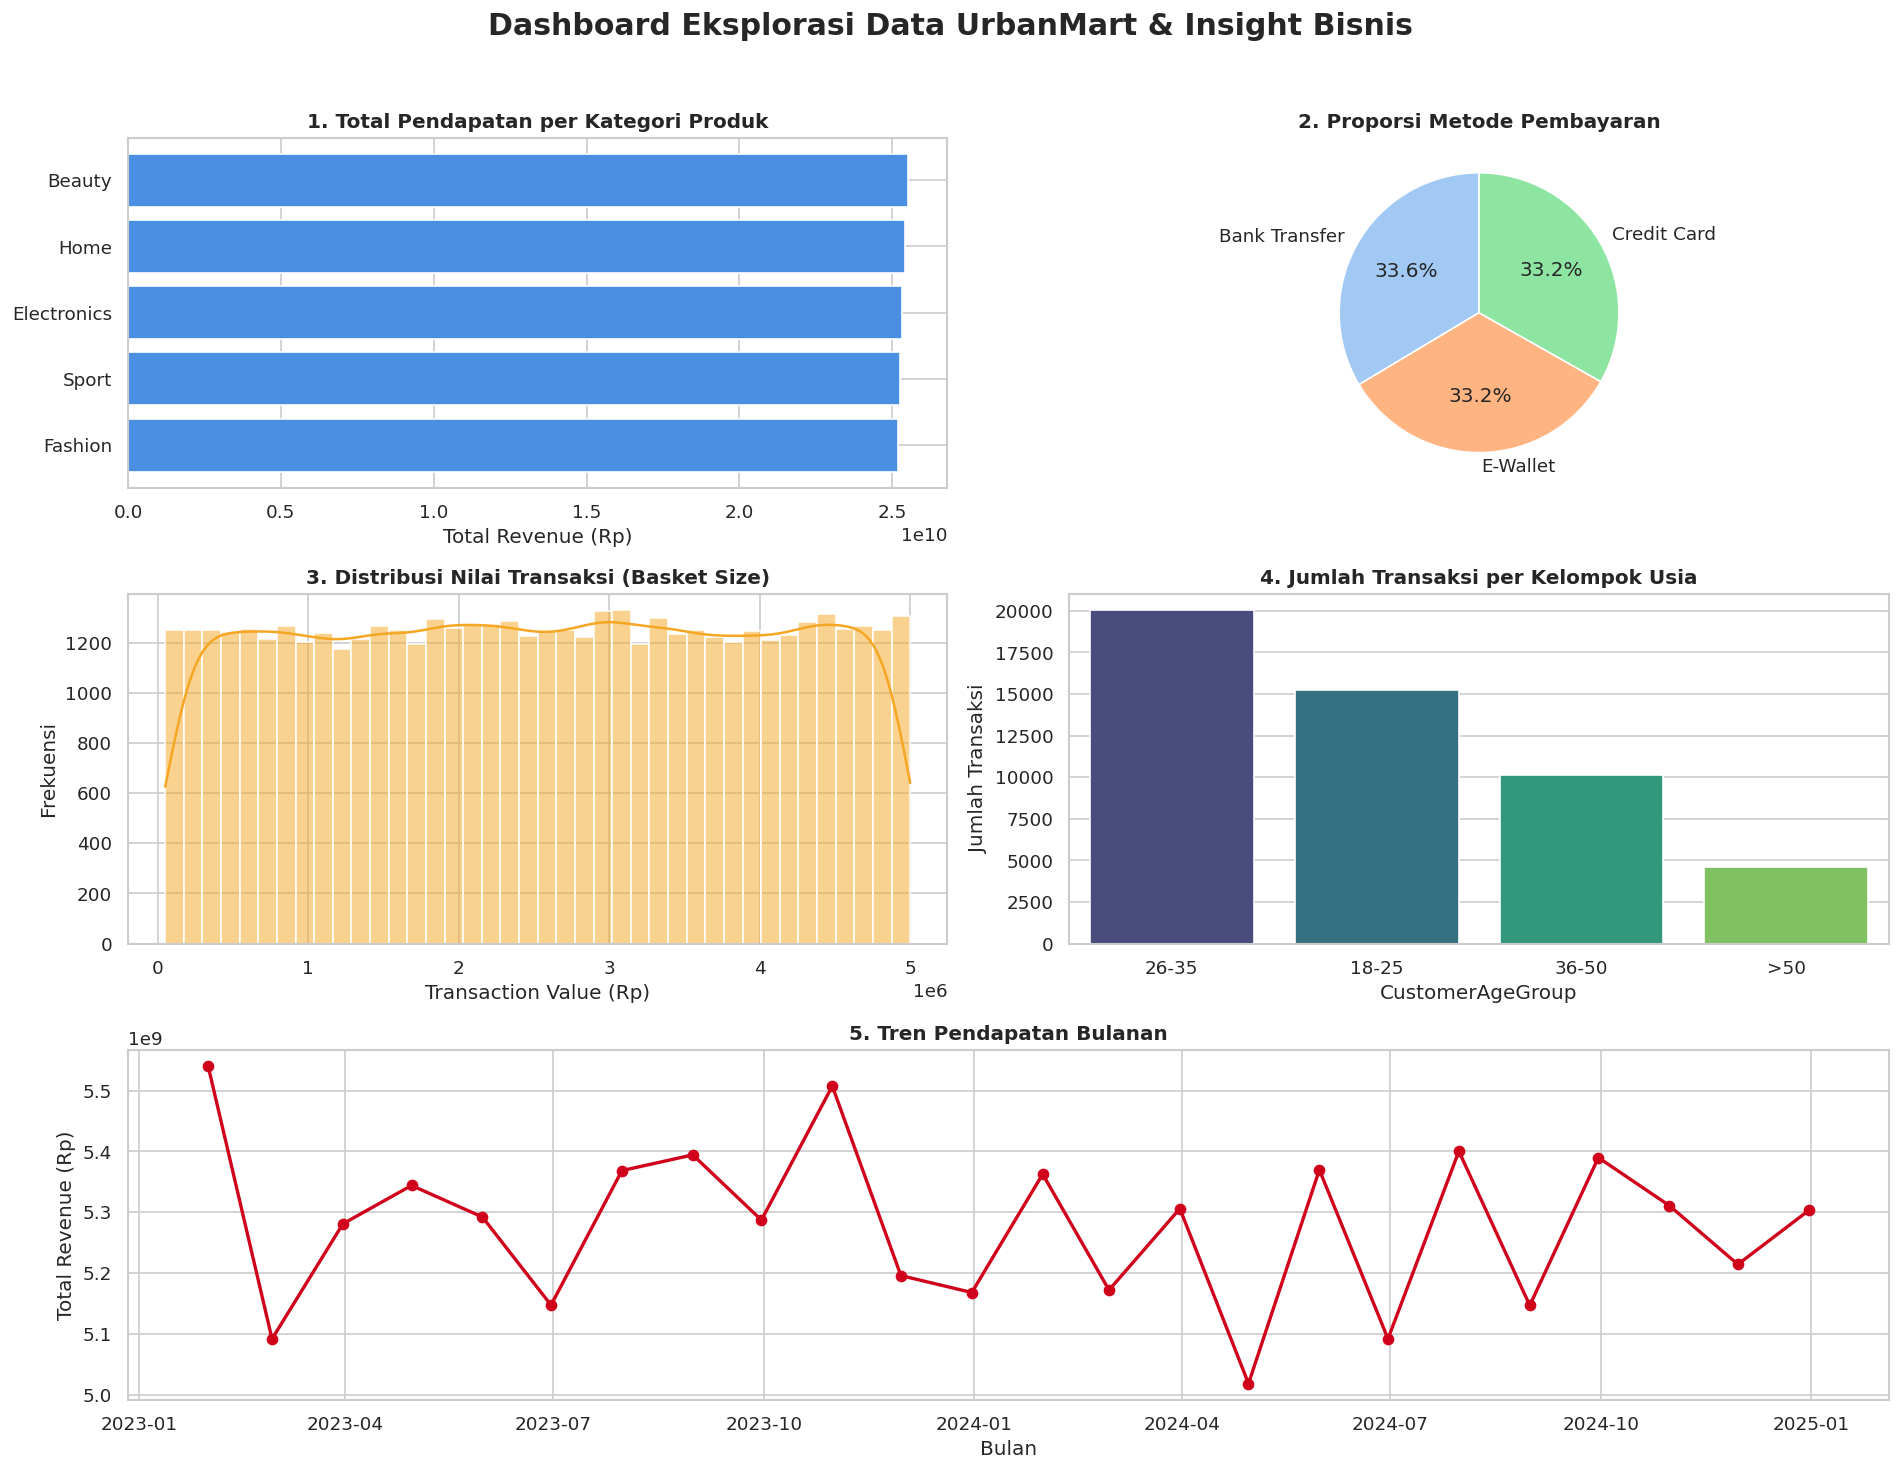

In [5]:
# ============================================================
# LANGKAH 4: ANALISIS BISNIS DASAR
# ============================================================
print('\nRINGKASAN BISNIS KESELURUHAN')
print('=' * 40)
print(f'Total Revenue    : Rp {df["TransactionValue"].sum():>18,.0f}')
print(f'Rata-rata Order  : Rp {df["TransactionValue"].mean():>18,.0f}')
print(f'Total Transaksi  : {df["TransactionID"].nunique():,}')
print(f'Total Pelanggan  : {df["CustomerID"].nunique():,}')

# ============================================================
# LANGKAH 5: VISUALISASI DASHBOARD EDA & INSIGHT BISNIS
# ============================================================
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Eksplorasi Data UrbanMart & Insight Bisnis', fontsize=18, fontweight='bold', y=1.02)

# Grid setup untuk 5 plot
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(3, 2, figure=fig)

# --- Plot 1: Revenue per Kategori Produk ---
ax1 = fig.add_subplot(gs[0, 0])
cat_sales = df.groupby('ProductCategory')['TransactionValue'].sum().sort_values(ascending=True)
ax1.barh(cat_sales.index, cat_sales.values, color='#4A90E2')
ax1.set_title('1. Total Pendapatan per Kategori Produk', fontweight='bold')
ax1.set_xlabel('Total Revenue (Rp)')

# --- Plot 2: Transaksi per Metode Pembayaran ---
ax2 = fig.add_subplot(gs[0, 1])
pay_counts = df['PaymentMethod'].value_counts()
ax2.pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
ax2.set_title('2. Proporsi Metode Pembayaran', fontweight='bold')

# --- Plot 3: Distribusi Nilai Transaksi ---
ax3 = fig.add_subplot(gs[1, 0])
sns.histplot(df['TransactionValue'], bins=40, kde=True, ax=ax3, color='#F5A623')
ax3.set_title('3. Distribusi Nilai Transaksi (Basket Size)', fontweight='bold')
ax3.set_xlabel('Transaction Value (Rp)')
ax3.set_ylabel('Frekuensi')

# --- Plot 4: Transaksi Berdasarkan Kelompok Usia ---
ax4 = fig.add_subplot(gs[1, 1])
age_counts = df['CustomerAgeGroup'].value_counts()
sns.barplot(x=age_counts.index, y=age_counts.values, ax=ax4, palette='viridis')
ax4.set_title('4. Jumlah Transaksi per Kelompok Usia', fontweight='bold')
ax4.set_ylabel('Jumlah Transaksi')

# --- Plot 5: Tren Transaksi Bulanan (Time Series) ---
ax5 = fig.add_subplot(gs[2, :])
monthly_sales = df.set_index('TransactionDate').resample('M')['TransactionValue'].sum()
ax5.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2, color='#D0021B')
ax5.set_title('5. Tren Pendapatan Bulanan', fontweight='bold')
ax5.set_xlabel('Bulan')
ax5.set_ylabel('Total Revenue (Rp)')

plt.tight_layout()
plt.savefig('urbanmart_eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()



In [6]:
# ============================================================
# LANGKAH 6: PERHITUNGAN R-F-M
# ============================================================
import datetime as dt

print('Mulai proses RFM Analysis...')

# 1. Tentukan tanggal referensi (1 hari setelah tanggal transaksi terakhir di dataset)
ref_date = df['TransactionDate'].max() + dt.timedelta(days=1)

# 2. Agregasi data per CustomerID untuk mendapatkan nilai R, F, dan M
rfm = df.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (ref_date - x.max()).days,  # Recency: Selisih hari
    'TransactionID': 'nunique',                              # Frequency: Jumlah transaksi unik
    'TransactionValue': 'sum'                                # Monetary: Total belanja
}).reset_index()

# Ubah nama kolom agar lebih intuitif
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f'\nShape Data RFM: {rfm.shape}')
print('\nSampel Data R-F-M (5 baris pertama):')
display(rfm.head())

Mulai proses RFM Analysis...

Shape Data RFM: (2000, 4)

Sampel Data R-F-M (5 baris pertama):


,CustomerID,Recency,Frequency,Monetary
0,CUST00001,1,22,63882371
1,CUST00002,18,23,57227590
2,CUST00003,22,28,76991379
3,CUST00004,10,33,87579881
4,CUST00005,21,33,96718054


In [7]:
# ============================================================
# LANGKAH 7: QUANTILE SCORING (1-5)
# ============================================================
# Kita gunakan pd.qcut untuk membagi data menjadi 5 kelompok (kuantil) yang sama besar.
# Catatan khusus Frequency: Kita gunakan .rank(method='first') agar terhindar dari
# error batas nilai duplikat (karena banyak pelanggan yang mungkin baru beli 1 kali).

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]) # R terbalik (makin kecil hari = makin baik = skor 5)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Pastikan tipe datanya integer agar bisa dijumlahkan & diolah dengan mudah
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Hitung Total Skor
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# ============================================================
# LANGKAH 8: PEMETAAN SEGMEN PELANGGAN (Sesuai Panduan Dosen)
# ============================================================
def assign_segment(row):
    r, f, m, total = row['R_Score'], row['F_Score'], row['M_Score'], row['RFM_Total']

    # Mapping menggunakan kombinasi kriteria spesifik (Slide 7) dan fallback Total Skor (Slide 5)
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f == 1:
        return 'New Customers'
    elif r >= 3 and f == 2:
        return 'Potential'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Hibernating'
    else:
        # Fallback berdasarkan RFM Total Score jika tidak masuk kriteria ketat di atas
        if total >= 10: return 'Loyal Customers'
        elif total >= 7: return 'Potential'
        else: return 'Hibernating'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# ============================================================
# LANGKAH 9: MEMBUAT TARGET KLASIFIKASI MACHINE LEARNING
# ============================================================
# Target biner: Champions (1) vs Lainnya (0)
rfm['Target_Champions'] = rfm['Segment'].apply(lambda x: 1 if x == 'Champions' else 0)

print('\nDistribusi Segmen Pelanggan:')
print(rfm['Segment'].value_counts())

print('\nDistribusi Target Machine Learning (1=Champions, 0=Lainnya):')
print(rfm['Target_Champions'].value_counts())


Distribusi Segmen Pelanggan:
Segment
Loyal Customers    766
Hibernating        440
Champions          306
Potential          272
New Customers      148
At Risk             68
Name: count, dtype: int64

Distribusi Target Machine Learning (1=Champions, 0=Lainnya):
Target_Champions
0    1694
1     306
Name: count, dtype: int64


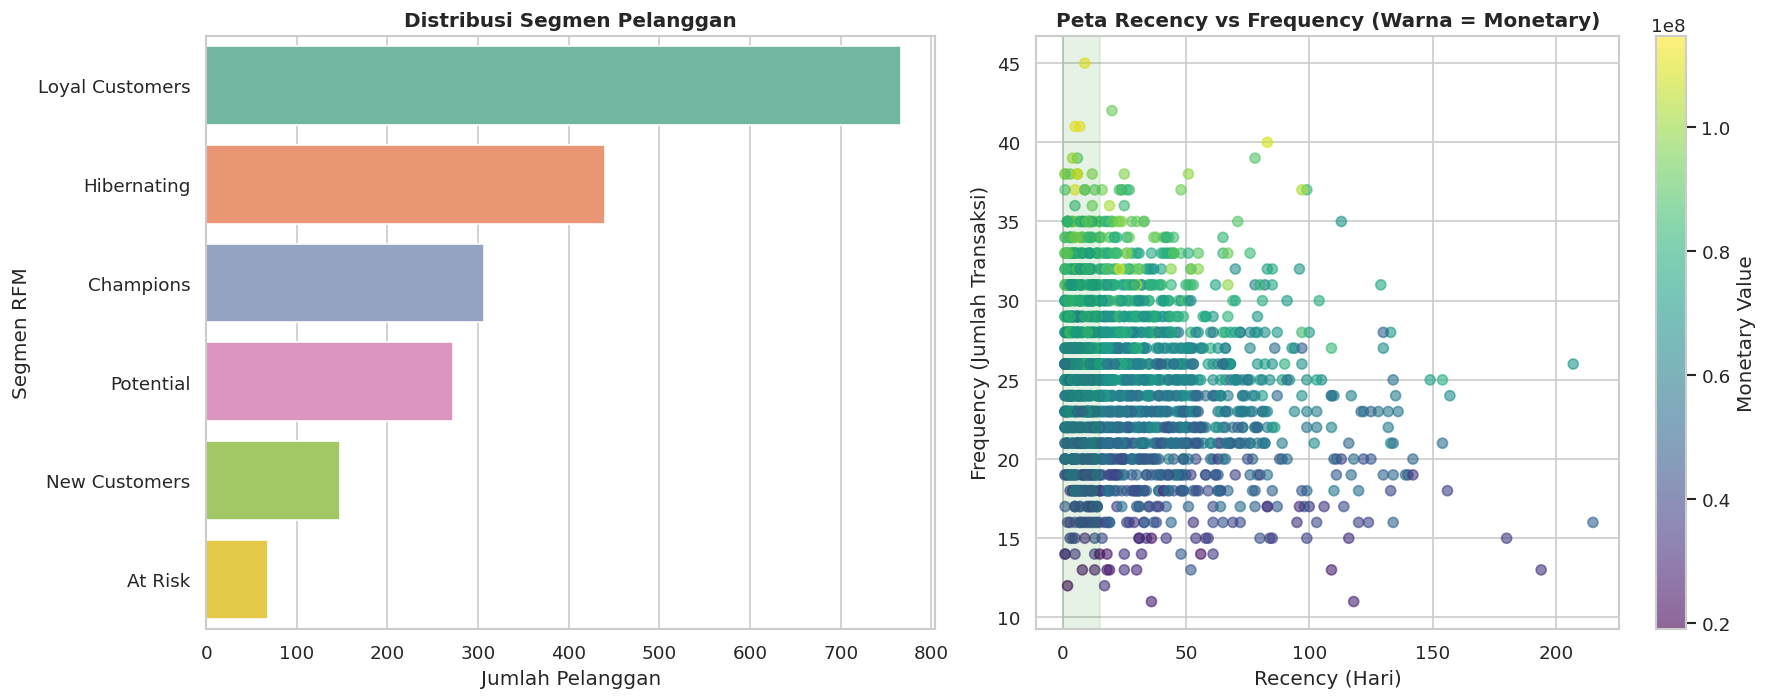


INSIGHT BISNIS BERDASARKAN RFM ANALYSIS:
1. Distribusi Segmen : Pelanggan yang masuk kategori 'Champions' akan menjadi fokus utama model ML kita.
   Rekomendasi       : Siapkan 'Loyalty Reward Eksklusif' untuk menjaga segmen Champions ini agar tidak churn, karena mereka adalah kontributor utama revenue.

2. Segmen Berisiko   : Perhatikan jumlah 'Hibernating' dan 'At Risk'.
   Rekomendasi       : Manajemen UMKM dapat meluncurkan Win-back campaign berisi diskon personal untuk mereka yang memiliki skor Frequency tinggi namun Recency rendah (At Risk).


In [8]:
# ============================================================
# LANGKAH 10: VISUALISASI PROFIL SEGMEN (Wajib untuk Rubrik)
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Bar Chart Jumlah Pelanggan per Segmen
segment_counts = rfm['Segment'].value_counts()
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='Set2', ax=ax[0])
ax[0].set_title('Distribusi Segmen Pelanggan', fontweight='bold')
ax[0].set_xlabel('Jumlah Pelanggan')
ax[0].set_ylabel('Segmen RFM')

# Plot 2: Scatter Plot R vs F (diwarnai berdasarkan M) khusus untuk melihat sebaran Champions
scatter = ax[1].scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Monetary'], cmap='viridis', alpha=0.6)
ax[1].set_title('Peta Recency vs Frequency (Warna = Monetary)', fontweight='bold')
ax[1].set_xlabel('Recency (Hari)')
ax[1].set_ylabel('Frequency (Jumlah Transaksi)')
plt.colorbar(scatter, ax=ax[1], label='Monetary Value')

# Beri anotasi area Champions
ax[1].axvspan(0, rfm[rfm['R_Score']>=4]['Recency'].max(), color='green', alpha=0.1, label='Area Recency Tinggi')

plt.tight_layout()
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight Bisnis Tertulis
print("\n" + "="*55)
print("INSIGHT BISNIS BERDASARKAN RFM ANALYSIS:")
print("="*55)
print("1. Distribusi Segmen : Pelanggan yang masuk kategori 'Champions' akan menjadi fokus utama model ML kita.")
print("   Rekomendasi       : Siapkan 'Loyalty Reward Eksklusif' untuk menjaga segmen Champions ini agar tidak churn, karena mereka adalah kontributor utama revenue.")
print("\n2. Segmen Berisiko   : Perhatikan jumlah 'Hibernating' dan 'At Risk'.")
print("   Rekomendasi       : Manajemen UMKM dapat meluncurkan Win-back campaign berisi diskon personal untuk mereka yang memiliki skor Frequency tinggi namun Recency rendah (At Risk).")

In [9]:
# ============================================================
# LANGKAH 11: FEATURE ENGINEERING UNTUK MACHINE LEARNING
# ============================================================
print('Menyiapkan dataset untuk Machine Learning...')

# Kita buat fitur prediktor (X) berdasarkan kebiasaan pelanggan
customer_features = df.groupby('CustomerID').agg(
    Avg_Transaction_Value=('TransactionValue', 'mean'),
    Most_Freq_Category=('ProductCategory', lambda x: x.mode()[0]),
    Most_Freq_Payment=('PaymentMethod', lambda x: x.mode()[0]),
    Age_Group=('CustomerAgeGroup', lambda x: x.mode()[0])
).reset_index()

# Gabungkan dengan target kelas (y) dari hasil RFM sebelumnya
ml_data = pd.merge(customer_features, rfm[['CustomerID', 'Target_Champions']], on='CustomerID')

# Pisahkan X (Fitur) dan y (Target)
X = ml_data.drop(['CustomerID', 'Target_Champions'], axis=1)
y = ml_data['Target_Champions']

print(f"Shape Fitur (X): {X.shape}")
print(f"Shape Target (y): {y.shape}")

Menyiapkan dataset untuk Machine Learning...
Shape Fitur (X): (2000, 4)
Shape Target (y): (2000,)


In [10]:
# ============================================================
# LANGKAH 12: TRAIN-TEST SPLIT & COLUMN TRANSFORMER PIPELINE
# ============================================================
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Train-Test Split (Gunakan stratify agar proporsi kelas 'Champions' seimbang di train & test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Pisahkan nama kolom numerik dan kategorikal
numeric_features = ['Avg_Transaction_Value']
categorical_features = ['Most_Freq_Category', 'Most_Freq_Payment', 'Age_Group']

# Buat Preprocessing Pipeline (Mencegah Data Leakage!)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])



In [11]:
# ============================================================
# LANGKAH 13: MODELING DENGAN 3 ALGORITMA & STRATIFIED CV
# ============================================================
# Cross-Validation 5-Fold (Define cv here, before GridSearchCV uses it)
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Inisialisasi 3 Model (Sesuai Syarat: LR, RF, + 1 Bebas)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42) # GB menggunakan pendekatan boosting, biarkan default
}


cv_results = []

print("\nSedang melatih model dan menghitung 5-fold CV...")
for name, model in models.items():
    # Gabungkan preprocessor dan model ke dalam Pipeline utuh
    clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    # Hitung metrik CV
    scores = cross_validate(clf_pipeline, X_train, y_train, cv=cv,
                            scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1 Score': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    })

# Tampilkan Tabel Perbandingan Model (Wajib Rubrik)
df_results = pd.DataFrame(cv_results).sort_values(by='ROC-AUC', ascending=False)
print("\nTABEL EVALUASI MODEL (CROSS-VALIDATION):")
display(df_results.round(4))


Sedang melatih model dan menghitung 5-fold CV...

TABEL EVALUASI MODEL (CROSS-VALIDATION):


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.8419,0.1333,0.0082,0.0154,0.5905
0,Logistic Regression,0.5444,0.1737,0.5265,0.2611,0.5390
1,Random Forest,0.7406,0.1288,0.1224,0.1251,0.5079


In [12]:
# ============================================================
# LANGKAH 14: HYPERPARAMETER TUNING (BEST MODEL)
# ============================================================
print("\nMelakukan Hyperparameter Tuning pada Random Forest...")

# Cross-Validation 5-Fold (Define cv here, before GridSearchCV uses it)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Kita pilih Random Forest untuk di-tune sebagai syarat wajib
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Tentukan parameter yang mau di-tuning
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

# Jalankan GridSearchCV
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train) # <- FIT HANYA DI X_TRAIN (No Leakage!)

best_model = grid_search.best_estimator_
print(f"Parameter Terbaik Random Forest: {grid_search.best_params_}")




Melakukan Hyperparameter Tuning pada Random Forest...
Parameter Terbaik Random Forest: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}



EVALUASI MODEL TERBAIK PADA DATA TEST (UNSEEN DATA):
Accuracy : 0.5875
Precision: 0.1667
Recall   : 0.4262
F1-Score : 0.2396
ROC-AUC  : 0.6096


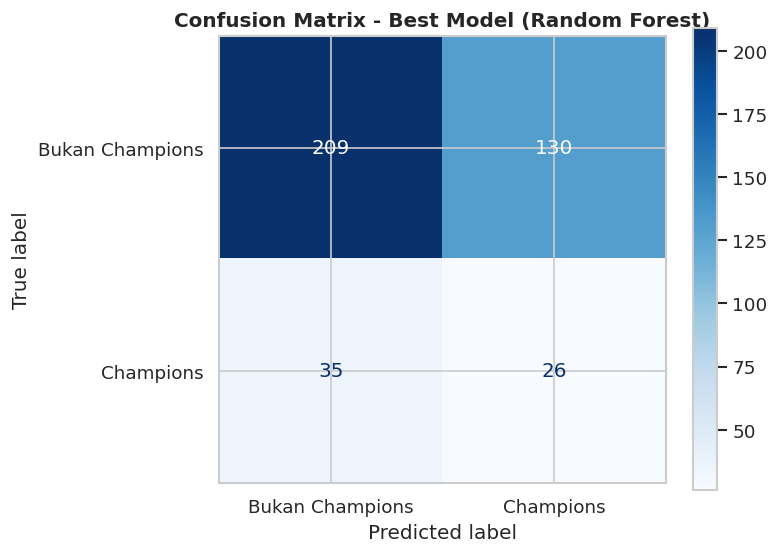

In [13]:
# ============================================================
# LANGKAH 15: EVALUASI PADA DATA TEST & CONFUSION MATRIX
# ============================================================
# Prediksi menggunakan data test
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nEVALUASI MODEL TERBAIK PADA DATA TEST (UNSEEN DATA):")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")

# Visualisasi Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bukan Champions', 'Champions'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Best Model (Random Forest)', fontweight='bold')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()